# Tests Scores:

In [1]:
import sys
sys.path.append('../')
sys.path.append('./git_clone_liibraries/')
import scipy.io as sio
import mat73
import pandas as pd
import torch
import numpy as np
import torch.optim as optim
import torch.nn
import sklearn
import sklearn.metrics
import matplotlib.pyplot as plt
from alive_progress import alive_bar
from  utils.my_classes import dataset 
from torch.utils.data import DataLoader
import utils.DNN_functions as DNN_functions
import scipy
import random
import utils.AMSloss
from speechbrain.pretrained import SpeakerRecognition
import pickle
import os
from utils.my_classes import dataset
import utils.eval_metrics as eval_metrics
import copy
from speechbrain.pretrained import SpeakerRecognition
# Plot histogram of predicted probabilities
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
import scipy
# Plot histogram of predicted probabilities
from matplotlib.ticker import PercentFormatter
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.isotonic import IsotonicRegression


seed = 42  # You can choose any integer value as the seed
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
# Set seed for Python's random module
random.seed(seed)
# Set seed for NumPy
np.random.seed(seed)
# Set seed for PyTorch (CPU and GPU, if available)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
# Set deterministic flags for PyTorch (if available)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\speechbrain\utils\torch_audio_backend.py:22: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\torch\onnx\_internal\_beartype.py:35: UserWarning: unhashable type: 'list'
  warnings.warn(f"{e}")
The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\speechbrain\utils\torch_audio_backend.py:22: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaud

In [2]:
#To get my GPU device - GTX 4070 :)
seed = 42  # You can choose any integer value as the seed
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');

if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.device(0))
    print(torch.cuda.get_device_name(0))
    print(device)

1
NVIDIA GeForce RTX 4070
cuda


In [3]:
from ASV_utils.data_loading import *



models_folder = "ECAPA_TDNN/inference_models/models_both_not_normalize/"

data_path_male = "Data/pmf_both/not_normalize/male/"

data_path_female = "Data/pmf_both/not_normalize/female/"

male_embedded_groups_1_1,male_embedded_groups_1_2,male_embedded_groups_1_3,male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id,male_chosen_labels_3_1_speaker_id,male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex  = load_data_male(data_path_male)

female_embedded_groups_1_1,female_embedded_groups_1_2,female_embedded_groups_1_3,female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex  = load_data_female(data_path_female)

# Pre Processing the channels And loading the Models - Male & Female:

In [4]:

import utils.my_functions as my_functions

columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)

female_embedded_groups_1_1 = female_embedded_groups_1_1[:,true_channels_indexes]
female_embedded_groups_1_2 = female_embedded_groups_1_2[:,true_channels_indexes]
female_embedded_groups_1_3 = female_embedded_groups_1_3[:,true_channels_indexes]

male_embedded_groups_1_1 = male_embedded_groups_1_1[:,true_channels_indexes]
male_embedded_groups_1_2 = male_embedded_groups_1_2[:,true_channels_indexes]
male_embedded_groups_1_3 = male_embedded_groups_1_3[:,true_channels_indexes]

In [5]:
from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract gammatone, gammatone_inv, channel number, and distance metric
    match = re.search(r'filter-(gammatone(?:_inv)?)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        gammatone = match.group(1)
        channel = int(match.group(2))
        distance_metric = match.group(3)

        # Assign a higher priority to distance_order, a medium priority to channels,
        # and lower priority to 'gammatone' and 'gammatone_inv'
        return (distance_metrics.index(distance_metric), channel, gammatone)

    else:
        # If the regex doesn't match, return the original item to maintain its position
        return (999, 999, "")

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    
male_embedded_groups_1_1 = male_embedded_groups_1_1[:,list(index_mapping.keys())]
male_embedded_groups_1_2 = male_embedded_groups_1_2[:,list(index_mapping.keys())]
male_embedded_groups_1_3 = male_embedded_groups_1_3[:,list(index_mapping.keys())]

female_embedded_groups_1_1 = female_embedded_groups_1_1[:,list(index_mapping.keys())]
female_embedded_groups_1_2 = female_embedded_groups_1_2[:,list(index_mapping.keys())]
female_embedded_groups_1_3 = female_embedded_groups_1_3[:,list(index_mapping.keys())]



In [6]:
# define the subchannel model network
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
import pickle
# define the subchannel model network
import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 

        
    def forward(self, x):
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        return x

# define the model network
class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,40)
        self.BN = nn.BatchNorm1d(40)
        self.fc = nn.Linear(40, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.loss = nn.BCEWithLogitsLoss()
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)



# Just for checking the model and see the number of parameters
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 5
final_output_size = 1
model = []
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size)
model = model.to(device)
print(model)
n = DNN.count_parameters(model)
print("Number of parameters: %s" % n)
model = model.to(device) # send the model to the device

model = pickle.load(open(models_folder + "CM_both_male_9_2.pkl", 'rb'))

model.eval()

spoof_model_male = copy.deepcopy(model)

DNN(
  (SubChannelNetwork): ModuleList(
    (0-15): 16 x SubChannelNetwork(
      (input_layer): Linear(in_features=10, out_features=5, bias=True)
      (sigmoid): Sigmoid()
      (dropout): Dropout(p=0.2, inplace=False)
      (BN_4): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fc_between_subnet): Linear(in_features=80, out_features=40, bias=True)
  (BN): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=40, out_features=1, bias=True)
  (sigmoid): Sigmoid()
  (droupout): Dropout(p=0.2, inplace=False)
  (loss): BCEWithLogitsLoss()
)
Number of parameters: 4401


In [7]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
from utils.OCSoftmaxloss import OCSoftmax
import torch.nn as nn

class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 
   
    def forward(self, x):
        res = x
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        x = res + x 
        return x

class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size, r_real , r_fake,alpha):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,40)
        self.BN = nn.BatchNorm1d(40)
        self.fc = nn.Linear(40, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.r_real = r_real
        self.r_fake = r_fake
        self.alpha = alpha
        self.loss = OCSoftmax(feat_dim = final_output_size, r_real = self.r_real, r_fake = self.r_fake, alpha = self.alpha)
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

r_real = 0.5 
r_fake = 0.1
alpha = 20
# Example usage
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 10
final_output_size = 16*3
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake = r_fake,alpha = alpha)


model = model.to(device) # send the model to the device

model = pickle.load(open(models_folder + "CM_both_female_10_17.pkl", 'rb'))

model.eval()

spoof_model_female = copy.deepcopy(model)


In [8]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
from utils.OCSoftmaxloss import OCSoftmax
import torch.nn as nn

import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 
   
    def forward(self, x):
        res = x
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        x = res + x 
        return x

class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size, r_real , r_fake,alpha):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,80)
        self.BN = nn.BatchNorm1d(80)
        self.fc = nn.Linear(80, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.r_real = r_real
        self.r_fake = r_fake
        self.alpha = alpha
        self.loss = OCSoftmax(feat_dim = final_output_size, r_real = self.r_real, r_fake = self.r_fake, alpha = self.alpha)
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)


r_real = 0.9 
r_fake = 0.5
alpha = 20
input_channel_size = 10
output_channel_size = 10
num_SubChannelNetwork = 16
final_output_size = 16*2
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake = r_fake,alpha = alpha)
model = model.to(device)


model = model.to(device) # send the model to the device

file_path = 'ECAPA_TDNN/inference_models/models_both_not_normalize/male_and_female_2_neorun_end_OCS_both_10_2.pkl'

# Load the variable from the pickle file
with open(file_path, 'rb') as file:
    model = pickle.load(file)

model.eval()

spoof_model = copy.deepcopy(model)


In [9]:
scaler_male = StandardScaler(with_mean = True, with_std = True)
scaler_male.fit(male_embedded_groups_1_1)
mean_features = scaler_male.mean_
std_features = scaler_male.scale_
male_embedded_groups_1_1_norm = scaler_male.transform(male_embedded_groups_1_1)
male_embedded_groups_1_2_norm = scaler_male.transform(male_embedded_groups_1_2)
male_embedded_groups_1_3_norm = scaler_male.transform(male_embedded_groups_1_3)


scaler_female = StandardScaler(with_mean = True, with_std = True)
scaler_female.fit(female_embedded_groups_1_1)
mean_features = scaler_female.mean_
std_features = scaler_female.scale_
female_embedded_groups_1_1_norm = scaler_female.transform(female_embedded_groups_1_1)
female_embedded_groups_1_2_norm = scaler_female.transform(female_embedded_groups_1_2)
female_embedded_groups_1_3_norm = scaler_female.transform(female_embedded_groups_1_3)

In [10]:
embedded_groups_1_1_norm,embedded_groups_1_2_norm,embedded_groups_1_3_norm,chosen_labels_1_1_is_spoofed,chosen_labels_2_1_is_spoofed,chosen_labels_3_1_is_spoofed,chosen_labels_numeric_1_1,chosen_labels_numeric_2_1,chosen_labels_numeric_3_1,chosen_labels_1_1_attack_logical,chosen_labels_2_1_attack_logical,chosen_labels_3_1_attack_logical,chosen_labels_1_1_name,chosen_labels_2_1_name,chosen_labels_3_1_name,chosen_labels_1_1_speaker_id,chosen_labels_2_1_speaker_id,chosen_labels_3_1_speaker_id,chosen_labels_1_1_sex,chosen_labels_2_1_sex,chosen_labels_3_1_sex    =  concatenate_data(male_embedded_groups_1_1_norm,male_embedded_groups_1_2_norm,male_embedded_groups_1_3_norm,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_embedded_groups_1_1_norm,female_embedded_groups_1_2_norm,female_embedded_groups_1_3_norm,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)


In [11]:
embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_    =  concatenate_data(male_embedded_groups_1_1,male_embedded_groups_1_2,male_embedded_groups_1_3,
                                                                                                                        male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                        male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                        male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                        male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                        male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                        male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                        
                                                                                                                        female_embedded_groups_1_1,female_embedded_groups_1_2,female_embedded_groups_1_3,
                                                                                                                        female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                        female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                        female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                        female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                        female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                        female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)
scaler_all = StandardScaler(with_mean = True, with_std = True)
scaler_all.fit(embedded_groups_1_1)
mean_features = scaler_female.mean_
std_features = scaler_female.scale_
embedded_groups_1_1_all = scaler_all.transform(embedded_groups_1_1)
embedded_groups_1_2_all = scaler_all.transform(embedded_groups_1_2)
embedded_groups_1_3_all = scaler_all.transform(embedded_groups_1_3)

In [12]:
train_dataset_all = dataset(data = embedded_groups_1_1_norm , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1,
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id, sex = chosen_labels_1_1_sex ,data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_1_all);

Dev_dataset_all = dataset(data = embedded_groups_1_2_norm , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1,
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = chosen_labels_2_1_sex ,  data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_2_all);


Eval_dataset_all = dataset(data = embedded_groups_1_3_norm , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1,
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id, sex = chosen_labels_3_1_sex , data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_3_all);


In [13]:
train_dataset_all.name = np.array([str(elem).split("/")[-1].split("'")[0].split('.flac')[0] for elem in train_dataset_all.name])

Dev_dataset_all.name = np.array([str(elem).split("/")[-1].split("'")[0].split('.flac')[0] for elem in Dev_dataset_all.name])

Eval_dataset_all.name = np.array([str(elem).split("/")[-1].split("'")[0].split('.flac')[0] for elem in Eval_dataset_all.name])

In [14]:
from ASV_utils.data_loading import *


models_folder = "ECAPA_TDNN/inference_models/models_both_not_normalize/"

data_path_male = "Data/male_vs_female_DB_models/16_bits/none/male/"

data_path_female = "Data/male_vs_female_DB_models/16_bits/none/female/"

g_male_embedded_groups_1_1,g_male_embedded_groups_1_2,g_male_embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_  = load_data_male(data_path_male)

g_female_embedded_groups_1_1,g_female_embedded_groups_1_2,g_female_embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_  = load_data_female(data_path_female)

embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_    =  concatenate_data(g_male_embedded_groups_1_1,g_male_embedded_groups_1_2,g_male_embedded_groups_1_3,
                                                                                                                    male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                    male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                    male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                    male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                    male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                    male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                    
                                                                                                                    g_female_embedded_groups_1_1,g_female_embedded_groups_1_2,g_female_embedded_groups_1_3,
                                                                                                                    female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                    female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                    female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                    female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                    female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                    female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)
chosen_labels_1_1_sex = np.array([elem[0] for elem in chosen_labels_1_1_sex])
                                 
chosen_labels_2_1_sex = np.array([elem[0] for elem in chosen_labels_2_1_sex])

chosen_labels_3_1_sex = np.array([elem[0] for elem in chosen_labels_3_1_sex])


In [15]:



import utils.my_functions as my_functions

columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)


embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]

from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract gammatone, gammatone_inv, channel number, and distance metric
    match = re.search(r'filter-(gammatone(?:_inv)?)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        gammatone = match.group(1)
        channel = int(match.group(2))
        distance_metric = match.group(3)

        # Assign a higher priority to distance_order, a medium priority to channels,
        # and lower priority to 'gammatone' and 'gammatone_inv'
        return (distance_metrics.index(distance_metric), channel, gammatone)

    else:
        # If the regex doesn't match, return the original item to maintain its position
        return (999, 999, "")

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    

embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]


columns_names = columns_names[list(index_mapping.keys())]

In [16]:
scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(embedded_groups_1_1)
mean_features = scaler.mean_
std_features = scaler.scale_

embedded_groups_1_1 = scaler.transform(embedded_groups_1_1)
embedded_groups_1_2 = scaler.transform(embedded_groups_1_2)
embedded_groups_1_3 = scaler.transform(embedded_groups_1_3)

train_dataset_all.data_for_gender_classification = embedded_groups_1_1
Dev_dataset_all.data_for_gender_classification   = embedded_groups_1_2
Eval_dataset_all.data_for_gender_classification  = embedded_groups_1_3


train_dataset_all.sex = pd.Series([elem[0] for elem in train_dataset_all.sex])
Dev_dataset_all.sex = pd.Series([elem[0] for elem in Dev_dataset_all.sex])
Eval_dataset_all.sex = pd.Series([elem[0] for elem in Eval_dataset_all.sex])


train_dataset_all.name = pd.Series([elem[0] for elem in train_dataset_all.name])
Dev_dataset_all.name = pd.Series([elem[0] for elem in Dev_dataset_all.name])
Eval_dataset_all.name = pd.Series([elem[0] for elem in Eval_dataset_all.name])

In [17]:
total_labels_dev_male = torch.Tensor(Dev_dataset_all.is_spoofed[(Dev_dataset_all.sex == 'male').values].values).cpu().numpy().copy()
total_data_dev_male = torch.Tensor(Dev_dataset_all.data[(Dev_dataset_all.sex == 'male').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    #test_score_dev_male = torch.sigmoid(spoof_model_male(torch.Tensor(total_data_dev_male).to(device)))
    test_score_dev_male = spoof_model_male(torch.Tensor(total_data_dev_male).to(device))
    
test_score_dev_male = test_score_dev_male.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels_dev_male,expit(test_score_dev_male)) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.007981601731367872%) 	Test Threshold: 0.15829723633162024


In [18]:
total_labels_eval_male = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'male').values].values).cpu().numpy().copy()
total_data_eval_male = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'male').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    #test_score_eval_male = torch.sigmoid(spoof_model_male(torch.Tensor(total_data_eval_male).to(device)))
    test_score_eval_male = spoof_model_male(torch.Tensor(total_data_eval_male).to(device))
    
test_score_eval_male = test_score_eval_male.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels_eval_male,expit(test_score_eval_male)) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")


	Test EER: (0.09203296703296708%) 	Test Threshold: 0.04938841153161375


In [19]:
total_labels_dev_female = torch.Tensor(Dev_dataset_all.is_spoofed[(Dev_dataset_all.sex == 'female').values].values).cpu().numpy().copy()
total_data_dev_female = torch.Tensor(Dev_dataset_all.data[(Dev_dataset_all.sex == 'female').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    test_output = spoof_model_female(torch.Tensor(total_data_dev_female).to(device))
    loss , test_score_dev_female = spoof_model_female.loss(torch.Tensor(test_output).to(device),None)
    test_score_dev_female = -1*test_score_dev_female
    
test_score_dev_female = test_score_dev_female.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels_dev_female,test_score_dev_female) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.0%) 	Test Threshold: nan


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in true_divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [20]:
total_labels_eval_female = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'female').values].values).cpu().numpy().copy()
total_data_eval_female = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'female').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    test_output = spoof_model_female(torch.Tensor(total_data_eval_female).to(device))
    loss , test_score_eval_female = spoof_model_female.loss(torch.Tensor(test_output).to(device),None)
    test_score_eval_female = -1*test_score_eval_female
    
test_score_eval_female = test_score_eval_female.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels_eval_female,test_score_eval_female) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.10177271288382395%) 	Test Threshold: -0.8237718060240031


In [21]:
dev_labels_all = torch.Tensor(Dev_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    validation_output = spoof_model(torch.Tensor(total_data).to(device)).cpu()
    loss , validation_score = spoof_model.loss(torch.Tensor(validation_output).to(device),torch.LongTensor(dev_labels_all).to(device))
    validation_score = -1*validation_score


dev_score_all = validation_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(dev_labels_all,dev_score_all) # compute equal error rate
print(f"\tTest EER: ({100*eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.039246467900462476%) 	Test Threshold: -0.9427753686997667


In [22]:
eval_labels_all = torch.Tensor(Eval_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    test_output = spoof_model(torch.Tensor(total_data).to(device))
    _ , test_score = spoof_model.loss(torch.Tensor(test_output).to(device),torch.LongTensor(eval_labels_all).to(device))
    test_score = -1*test_score
    
eval_score_all = test_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(eval_labels_all,eval_score_all) # compute equal error rate


print(f"\tTest EER: ({100*eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (10.273629504398746%) 	Test Threshold: -0.996142029976868


In [23]:
import numpy as np
import sklearn.metrics
from confidence_intervals import evaluate_with_conf_int
from confidence_intervals import get_bootstrap_indices, get_conf_int
from confidence_intervals.utils import barplot_with_ci
import warnings
warnings.filterwarnings("ignore")
# Percentage for the confidence interval
alpha = 5 

# Number of bootstrap samples to use (the run time will be proportional to this number). We set it to
# 50/alpha*100 to get enough samples in the tails.
num_bootstraps = int(50/alpha*100) # 1000

print(" Number of bootstraps: ", num_bootstraps)
print(" Alpha: ", alpha)

def metric(labels, scores):
    eer, _ = my_functions.compute_eer(labels, scores)
    if eer == 0:
        epsilon = 1e-10
        eer = eer + epsilon
    return eer*100

##Male:

results_list_dev_male = pickle.load(open('asv_results_dev_fixed_male.pkl','rb'))
labels = results_list_dev_male.loc[(results_list_dev_male['label_ground_truth'] == "target") | (results_list_dev_male['label_ground_truth'] == "nontarget")]["label_ground_truth"].values
scores = results_list_dev_male.loc[(results_list_dev_male['label_ground_truth'] == "target") | (results_list_dev_male['label_ground_truth'] == "nontarget")]["pred_scores"].values
speakers = results_list_dev_male.loc[(results_list_dev_male['label_ground_truth'] == "target") | (results_list_dev_male['label_ground_truth'] == "nontarget")]["speaker_id"].values
labels[labels == "target"] = 1
labels[labels == "nontarget"] = 0
labels = labels.astype(int)
res_dev_male = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha)

results_list_eval_male = pickle.load(open('asv_results_eval_fixed_male.pkl','rb'))
labels = results_list_eval_male.loc[(results_list_eval_male['label_ground_truth'] == "target") | (results_list_eval_male['label_ground_truth'] == "nontarget")]["label_ground_truth"].values
scores = results_list_eval_male.loc[(results_list_eval_male['label_ground_truth'] == "target") | (results_list_eval_male['label_ground_truth'] == "nontarget")]["pred_scores"].values
speakers = results_list_eval_male.loc[(results_list_eval_male['label_ground_truth'] == "target") | (results_list_eval_male['label_ground_truth'] == "nontarget")]["speaker_id"].values
labels[labels == "target"] = 1
labels[labels == "nontarget"] = 0
labels = labels.astype(int)
res_eval_male = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha)

##Female:

results_list_dev_female = pickle.load(open('asv_results_dev_fixed_female.pkl','rb'))
labels = results_list_dev_female.loc[(results_list_dev_female['label_ground_truth'] == "target") | (results_list_dev_female['label_ground_truth'] == "nontarget")]["label_ground_truth"].values
scores = results_list_dev_female.loc[(results_list_dev_female['label_ground_truth'] == "target") | (results_list_dev_female['label_ground_truth'] == "nontarget")]["pred_scores"].values
speakers = results_list_dev_female.loc[(results_list_dev_female['label_ground_truth'] == "target") | (results_list_dev_female['label_ground_truth'] == "nontarget")]["speaker_id"].values
labels[labels == "target"] = 1
labels[labels == "nontarget"] = 0
labels = labels.astype(int)
res_dev_female = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, num_bootstraps=num_bootstraps, alpha=alpha)


results_list_eval_female = pickle.load(open('asv_results_eval_fixed_female.pkl','rb'))
labels = results_list_eval_female.loc[(results_list_eval_female['label_ground_truth'] == "target") | (results_list_eval_female['label_ground_truth'] == "nontarget")]["label_ground_truth"].values
scores = results_list_eval_female.loc[(results_list_eval_female['label_ground_truth'] == "target") | (results_list_eval_female['label_ground_truth'] == "nontarget")]["pred_scores"].values
speakers = results_list_eval_female.loc[(results_list_eval_female['label_ground_truth'] == "target") | (results_list_eval_female['label_ground_truth'] == "nontarget")]["speaker_id"].values
labels[labels == "target"] = 1
labels[labels == "nontarget"] = 0
labels = labels.astype(int)
res_eval_female = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, num_bootstraps=num_bootstraps, alpha=alpha)


#All:

results_list_dev_all = pickle.load(open('asv_results_dev_fixed_all.pkl','rb'))
labels = results_list_dev_all.loc[(results_list_dev_all['label_ground_truth'] == "target") | (results_list_dev_all['label_ground_truth'] == "nontarget")]["label_ground_truth"].values
scores = results_list_dev_all.loc[(results_list_dev_all['label_ground_truth'] == "target") | (results_list_dev_all['label_ground_truth'] == "nontarget")]["pred_scores"].values
speakers = results_list_dev_all.loc[(results_list_dev_all['label_ground_truth'] == "target") | (results_list_dev_all['label_ground_truth'] == "nontarget")]["speaker_id"].values
labels[labels == "target"] = 1
labels[labels == "nontarget"] = 0
labels = labels.astype(int)
res_dev_all = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha)


results_list_eval_all = pickle.load(open('asv_results_eval_fixed_all.pkl','rb'))
labels = results_list_eval_all.loc[(results_list_eval_all['label_ground_truth'] == "target") | (results_list_eval_all['label_ground_truth'] == "nontarget")]["label_ground_truth"].values
scores = results_list_eval_all.loc[(results_list_eval_all['label_ground_truth'] == "target") | (results_list_eval_all['label_ground_truth'] == "nontarget")]["pred_scores"].values
speakers = results_list_eval_all.loc[(results_list_eval_all['label_ground_truth'] == "target") | (results_list_eval_all['label_ground_truth'] == "nontarget")]["speaker_id"].values
labels[labels == "target"] = 1
labels[labels == "nontarget"] = 0
labels = labels.astype(int)
res_eval_all = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha)



data = {}
data['Male'] = {'Dev': res_dev_male, 'Eval': res_eval_male}
data['Female'] = {'Dev': res_dev_female, 'Eval': res_eval_female}
data['all'] = {'Dev': res_dev_all, 'Eval': res_eval_all}

 Number of bootstraps:  1000
 Alpha:  5


{'Dev': (0.3571428571428544, (1e-08, 0.9677731933254321)), 'Eval': (0.6302521008400728, (0.17006802728234377, 1.2089907925876273))}
{'Dev': (1.0822510822512599, (0.739857524898003, 1.503003576368717)), 'Eval': (0.7864028411973685, (0.6628604325532893, 0.9628078701780326))}
{'Dev': (1.3477088948720872, (0.39514915670502104, 2.4841292184460357)), 'Eval': (0.8011522188394626, (0.47232090239874513, 1.1849684998574765))}


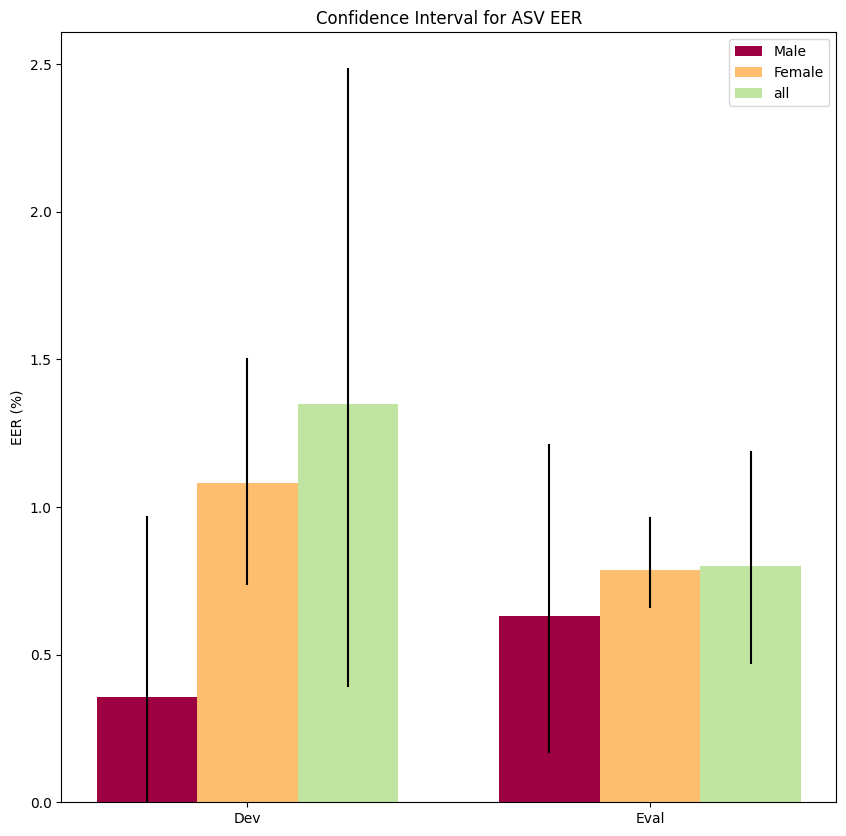

In [24]:
barplot_with_ci(data, figsize=(10,10),y_limit = [1,1],eer = True,title = 'Confidence Interval for ASV EER')

In [25]:
# load the model - the moodel that check if it's female or male
with open(os.path.join(models_folder,"gender_XGB_model_both_norm_male_vs_female_db_models.pkl"), 'rb') as fp:
#with open(os.path.join(models_folder,"gender_XGB_model_both_norm_male_vs_female_db_models.pkl"), 'rb') as fp:
    gender_model = pickle.load(fp)

In [26]:
labels_dev_male_gender_classification = torch.Tensor(Dev_dataset_all.is_spoofed[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    score_dev_male_gender_classification = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
score_dev_male_gender_classification = score_dev_male_gender_classification.cpu().numpy().copy()

eval_male_eer, _ = my_functions.compute_eer(labels_dev_male_gender_classification,score_dev_male_gender_classification) # compute equal error rate

print(f"\tEval male with gender classification EER: ({100*eval_male_eer}%) ")

	Eval male with gender classification EER: (0.7981601731367872%) 


In [27]:
labels_eval_male_gender_classification = torch.Tensor(Eval_dataset_all.is_spoofed[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    score_eval_male_gender_classification = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
score_eval_male_gender_classification = score_eval_male_gender_classification.cpu().numpy().copy()

eval_male_eer, _ = my_functions.compute_eer(labels_eval_male_gender_classification,score_eval_male_gender_classification) # compute equal error rate

print(f"\tEval male with gender classification EER: ({100*eval_male_eer}%) ")

	Eval male with gender classification EER: (9.069893266440404%) 


In [28]:
labels_dev_female_gender_classification = torch.Tensor(Dev_dataset_all.is_spoofed[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 0].values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 0]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    output = spoof_model_female(torch.Tensor(total_data).to(device))
    _ , score_dev_female_gender_classification = spoof_model_female.loss(torch.Tensor(output).to(device),None)
    score_dev_female_gender_classification = -1*score_dev_female_gender_classification
    
score_dev_female_gender_classification = score_dev_female_gender_classification.cpu().numpy().copy()

eer, _ = my_functions.compute_eer(labels_dev_female_gender_classification,score_dev_female_gender_classification) # compute equal error rate

print(f"\tDev Female EER:({100*eer}%)")

	Dev Female EER:(0.0%)


In [29]:
labels_eval_female_gender_classification = torch.Tensor(Eval_dataset_all.is_spoofed[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 0].values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 0]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    output = spoof_model_female(torch.Tensor(total_data).to(device))
    _ , score_eval_female_gender_classification = spoof_model_female.loss(torch.Tensor(output).to(device),None)
    score_eval_female_gender_classification = -1*score_eval_female_gender_classification
    
score_eval_female_gender_classification = score_eval_female_gender_classification.cpu().numpy().copy()

eer, _ = my_functions.compute_eer(labels_eval_female_gender_classification,score_eval_female_gender_classification) # compute equal error rate

print(f"\tDev Female EER:({100*eer}%)")

	Dev Female EER:(10.318936419363473%)


# Dev

In [30]:
import numpy as np
import sklearn.metrics
from confidence_intervals import evaluate_with_conf_int
from confidence_intervals import get_bootstrap_indices, get_conf_int
from confidence_intervals.utils import barplot_with_ci
import pickle
from ASV_utils.dcf_my_functions import dcf_formula
import warnings
warnings.filterwarnings("ignore")
# Percentage for the confidence interval
alpha = 5 

# Number of bootstrap samples to use (the run time will be proportional to this number). We set it to
# 50/alpha*100 to get enough samples in the tails.
num_bootstraps = int(50/alpha*100) # 1000

print(" Number of bootstraps: ", num_bootstraps)
print(" Alpha: ", alpha)



results_list_dev_all = pickle.load(open('asv_results_dev_fixed_all.pkl','rb'))
results_list_eval_all = pickle.load(open('asv_results_eval_fixed_all.pkl','rb'))

def metric(labels, scores):
  Prior_target =  0.99

  Prior_non_target = 1-Prior_target

  cost_model_dcf = {
        'Cmiss_asv': 1,      # Cost of ASV falsely rejecting target
        'Cfa_asv': 10}       # Cost of ASV falsely accepting nontarget
  dcf_list = []
  tar_female_idx = np.where(labels == 3)[0]
  non_female_idx = np.where(labels == 2)[0]
  tar_male_idx = np.where(labels == 1)[0]
  non_male_idx = np.where(labels == 0)[0]
  
  nontarget_scores_female = scores[non_female_idx]
  target_scores_female = scores[tar_female_idx]
  nontarget_scores_male = scores[non_male_idx]
  target_scores_male = scores[tar_male_idx]
  
  asv_score_female_wizard = 0.33
  asv_score_male_wizard = 0.247 # Dev MALE
  
  summing_female_nontar = np.sum(nontarget_scores_female >= asv_score_female_wizard)
  summing_female_tar =  np.sum(target_scores_female < asv_score_female_wizard)
  summing_male_nontar = np.sum(nontarget_scores_male >= asv_score_male_wizard)
  summing_male_tar =  np.sum(target_scores_male < asv_score_male_wizard)
  
  Pmiss_asv = (summing_female_tar + summing_male_tar) / (target_scores_male.size+target_scores_female.size)
  Pfa_asv = (summing_female_nontar +  summing_male_nontar )/ (nontarget_scores_male.size+nontarget_scores_female.size)

  dcf = dcf_formula(Pfa_asv,Pmiss_asv,Prior_target = Prior_target,Prior_non_target= Prior_non_target,cost_model_dcf=cost_model_dcf,is_print=False)

  dcf_list.append(dcf)
  
  return np.min(dcf_list)


#All MGG:
#DEV
gender_type = "male"
target_scores_male = results_list_dev_all.loc[(results_list_dev_all['gender'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_male =results_list_dev_all.loc[(results_list_dev_all['gender'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "nontarget")]["pred_scores"]

gender_type = "female"
target_scores_female = results_list_dev_all.loc[(results_list_dev_all['gender'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_female =results_list_dev_all.loc[(results_list_dev_all['gender'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "nontarget")]["pred_scores"]

scores_male = np.concatenate((target_scores_male,nontarget_scores_male))

labels_male = np.concatenate((np.ones(len(target_scores_male)),np.zeros(len(nontarget_scores_male))))


scores_female = np.concatenate((target_scores_female,nontarget_scores_female))

labels_female = np.concatenate((np.ones(len(target_scores_female)),np.zeros(len(nontarget_scores_female))))


cond = (results_list_dev_all['label_ground_truth'] == "target") | (results_list_dev_all['label_ground_truth'] == "nontarget")
labels_female[labels_female == 1] = 3
labels_female[labels_female == 0] = 2

labels = np.concatenate((labels_male,labels_female))
scores = np.concatenate((scores_male,scores_female))
speakers = results_list_dev_all.loc[cond]["speaker_id"].values

labels = labels.astype(int)
res_dev_all = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha,samples2 = None)
res_dev_all


 Number of bootstraps:  1000
 Alpha:  5


(0.006655980948891742, (0.0019145613451372508, 0.013242397186114531))

# Eval

In [31]:
def metric(labels, scores):
    Prior_target =  0.99

    Prior_non_target = 1-Prior_target

    cost_model_dcf = {
        'Cmiss_asv': 1,      # Cost of ASV falsely rejecting target
        'Cfa_asv': 10}       # Cost of ASV falsely accepting nontarget
    dcf_list = []
    tar_female_idx = np.where(labels == 3)[0]
    non_female_idx = np.where(labels == 2)[0]
    tar_male_idx = np.where(labels == 1)[0]
    non_male_idx = np.where(labels == 0)[0]

    nontarget_scores_female = scores[non_female_idx]
    target_scores_female = scores[tar_female_idx]
    nontarget_scores_male = scores[non_male_idx]
    target_scores_male = scores[tar_male_idx]

    asv_score_female_wizard = 0.346
    asv_score_male_wizard = 0.310

    summing_female_nontar = np.sum(nontarget_scores_female >= asv_score_female_wizard)
    summing_female_tar =  np.sum(target_scores_female < asv_score_female_wizard)
    summing_male_nontar = np.sum(nontarget_scores_male >= asv_score_male_wizard)
    summing_male_tar =  np.sum(target_scores_male < asv_score_male_wizard)

    Pmiss_asv = (summing_female_tar + summing_male_tar) / (target_scores_male.size+target_scores_female.size)
    Pfa_asv = (summing_female_nontar +  summing_male_nontar )/ (nontarget_scores_male.size+nontarget_scores_female.size)

    dcf = dcf_formula(Pfa_asv,Pmiss_asv,Prior_target = Prior_target,Prior_non_target= Prior_non_target,cost_model_dcf=cost_model_dcf,is_print=False)

    dcf_list.append(dcf)

    return np.min(dcf_list)

#EVAL
#All MGG:
#EVAL
gender_type = "male"
target_scores_male = results_list_eval_all.loc[(results_list_eval_all['gender'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_male =results_list_eval_all.loc[(results_list_eval_all['gender'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "nontarget")]["pred_scores"]

gender_type = "female"
target_scores_female = results_list_eval_all.loc[(results_list_eval_all['gender'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_female = results_list_eval_all.loc[(results_list_eval_all['gender'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "nontarget")]["pred_scores"]

scores_male = np.concatenate((target_scores_male,nontarget_scores_male))

labels_male = np.concatenate((np.ones(len(target_scores_male)),np.zeros(len(nontarget_scores_male))))

scores_female = np.concatenate((target_scores_female,nontarget_scores_female))

labels_female = np.concatenate((np.ones(len(target_scores_female)),np.zeros(len(nontarget_scores_female))))

cond = (results_list_eval_all['label_ground_truth'] == "target") | (results_list_eval_all['label_ground_truth'] == "nontarget")
labels_female[labels_female == 1] = 3
labels_female[labels_female == 0] = 2

labels = np.concatenate((labels_male,labels_female))
scores = np.concatenate((scores_male,scores_female))
speakers = results_list_eval_all.loc[cond]["speaker_id"].values

labels = labels.astype(int)
res_eval_all = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha,samples2 = None)

data = {}
data['MGG'] = {'Dev': res_dev_all, 'Eval': res_eval_all}
res_eval_all

(0.004458394748633528, (0.002427461341456329, 0.007397342154509093))

# Dev with gender classification

In [32]:
def metric(labels, scores):
    Prior_target =  0.99

    Prior_non_target = 1-Prior_target

    cost_model_dcf = {
        'Cmiss_asv': 1,      # Cost of ASV falsely rejecting target
        'Cfa_asv': 10,       # Cost of ASV falsely accepting nontarget
    }
    dcf_list = []
    tar_female_idx = np.where(labels == 3)[0]
    non_female_idx = np.where(labels == 2)[0]
    tar_male_idx = np.where(labels == 1)[0]
    non_male_idx = np.where(labels == 0)[0]
    
    nontarget_scores_female = scores[non_female_idx]
    target_scores_female = scores[tar_female_idx]
    nontarget_scores_male = scores[non_male_idx]
    target_scores_male = scores[tar_male_idx]
    
    asv_score_female_wizard = 0.330
    asv_score_male_wizard = 0.247
    
    summing_female_nontar = np.sum(nontarget_scores_female >= asv_score_female_wizard)
    summing_female_tar =  np.sum(target_scores_female < asv_score_female_wizard)
    summing_male_nontar = np.sum(nontarget_scores_male >= asv_score_male_wizard)
    summing_male_tar =  np.sum(target_scores_male < asv_score_male_wizard)
    
    Pmiss_asv = (summing_female_tar + summing_male_tar) / (target_scores_male.size+target_scores_female.size)
    Pfa_asv = (summing_female_nontar +  summing_male_nontar )/ (nontarget_scores_male.size+nontarget_scores_female.size)
        
    dcf = dcf_formula(Pfa_asv,Pmiss_asv,Prior_target = Prior_target,Prior_non_target= Prior_non_target,cost_model_dcf=cost_model_dcf,is_print=False)
   
    
    dcf_list.append(dcf)

    return np.min(dcf_list)


#All MGG - WITH GENDER CLASSIFICATION:
#DEV
gender_type = True
target_scores_male = results_list_dev_all.loc[(results_list_dev_all['gender_pred'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_male =results_list_dev_all.loc[(results_list_dev_all['gender_pred'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "nontarget")]["pred_scores"]

gender_type = False
target_scores_female = results_list_dev_all.loc[(results_list_dev_all['gender_pred'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_female =results_list_dev_all.loc[(results_list_dev_all['gender_pred'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "nontarget")]["pred_scores"]

scores_male = np.concatenate((target_scores_male,nontarget_scores_male))

labels_male = np.concatenate((np.ones(len(target_scores_male)),np.zeros(len(nontarget_scores_male))))

scores_female = np.concatenate((target_scores_female,nontarget_scores_female))

labels_female = np.concatenate((np.ones(len(target_scores_female)),np.zeros(len(nontarget_scores_female))))

cond = (results_list_dev_all['label_ground_truth'] == "target") | (results_list_dev_all['label_ground_truth'] == "nontarget")
labels_female[labels_female == 1] = 3
labels_female[labels_female == 0] = 2

labels = np.concatenate((labels_male,labels_female))
scores = np.concatenate((scores_male,scores_female))
speakers = results_list_dev_all.loc[cond]["speaker_id"].values

labels = labels.astype(int)
res_dev_all_with_gender = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha,samples2 = None)


res_dev_all_with_gender

(0.006655980948891742, (0.0019145613451372508, 0.013242397186114531))

# Eval with gender classification

In [33]:
def metric(labels, scores):
    Prior_target =  0.99

    Prior_non_target = 1-Prior_target

    cost_model_dcf = {
        'Cmiss_asv': 1,      # Cost of ASV falsely rejecting target
        'Cfa_asv': 10,       # Cost of ASV falsely accepting nontarget
    }
    dcf_list = []
    tar_female_idx = np.where(labels == 3)[0]
    non_female_idx = np.where(labels == 2)[0]
    tar_male_idx = np.where(labels == 1)[0]
    non_male_idx = np.where(labels == 0)[0]
    
    nontarget_scores_female = scores[non_female_idx]
    target_scores_female = scores[tar_female_idx]
    nontarget_scores_male = scores[non_male_idx]
    target_scores_male = scores[tar_male_idx]
    
    asv_score_female_wizard = 0.346
    asv_score_male_wizard = 0.310
    
    summing_female_nontar = np.sum(nontarget_scores_female >= asv_score_female_wizard)
    summing_female_tar =  np.sum(target_scores_female < asv_score_female_wizard)
    summing_male_nontar = np.sum(nontarget_scores_male >= asv_score_male_wizard)
    summing_male_tar =  np.sum(target_scores_male < asv_score_male_wizard)
    
    Pmiss_asv = (summing_female_tar + summing_male_tar) / (target_scores_male.size+target_scores_female.size)
    Pfa_asv = (summing_female_nontar +  summing_male_nontar )/ (nontarget_scores_male.size+nontarget_scores_female.size)
        
    dcf = dcf_formula(Pfa_asv,Pmiss_asv,Prior_target = Prior_target,Prior_non_target= Prior_non_target,cost_model_dcf=cost_model_dcf,is_print=False)
   
    
    dcf_list.append(dcf)

    return np.min(dcf_list)

gender_type = True
target_scores_male = results_list_eval_all.loc[(results_list_eval_all['gender_pred'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_male =results_list_eval_all.loc[(results_list_eval_all['gender_pred'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "nontarget")]["pred_scores"]

gender_type = False
target_scores_female = results_list_eval_all.loc[(results_list_eval_all['gender_pred'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_female = results_list_eval_all.loc[(results_list_eval_all['gender_pred'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "nontarget")]["pred_scores"]

scores_male = np.concatenate((target_scores_male,nontarget_scores_male))

labels_male = np.concatenate((np.ones(len(target_scores_male)),np.zeros(len(nontarget_scores_male))))

scores_female = np.concatenate((target_scores_female,nontarget_scores_female))

labels_female = np.concatenate((np.ones(len(target_scores_female)),np.zeros(len(nontarget_scores_female))))

cond = (results_list_eval_all['label_ground_truth'] == "target") | (results_list_eval_all['label_ground_truth'] == "nontarget")
labels_female[labels_female == 1] = 3
labels_female[labels_female == 0] = 2

labels = np.concatenate((labels_male,labels_female))
scores = np.concatenate((scores_male,scores_female))
speakers = results_list_eval_all.loc[cond]["speaker_id"].values

labels = labels.astype(int)
res_eval_all_with_gender = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha,samples2 = None)

data['MGG_with_gender'] = {'Dev': res_dev_all_with_gender, 'Eval': res_eval_all_with_gender}
res_eval_all_with_gender

(0.004449393038308566, (0.0024304788949493328, 0.007154413071616485))

{'Dev': (0.006655980948891742, (0.0019145613451372508, 0.013242397186114531)), 'Eval': (0.004458394748633528, (0.002427461341456329, 0.007397342154509093))}
{'Dev': (0.006655980948891742, (0.0019145613451372508, 0.013242397186114531)), 'Eval': (0.004449393038308566, (0.0024304788949493328, 0.007154413071616485))}


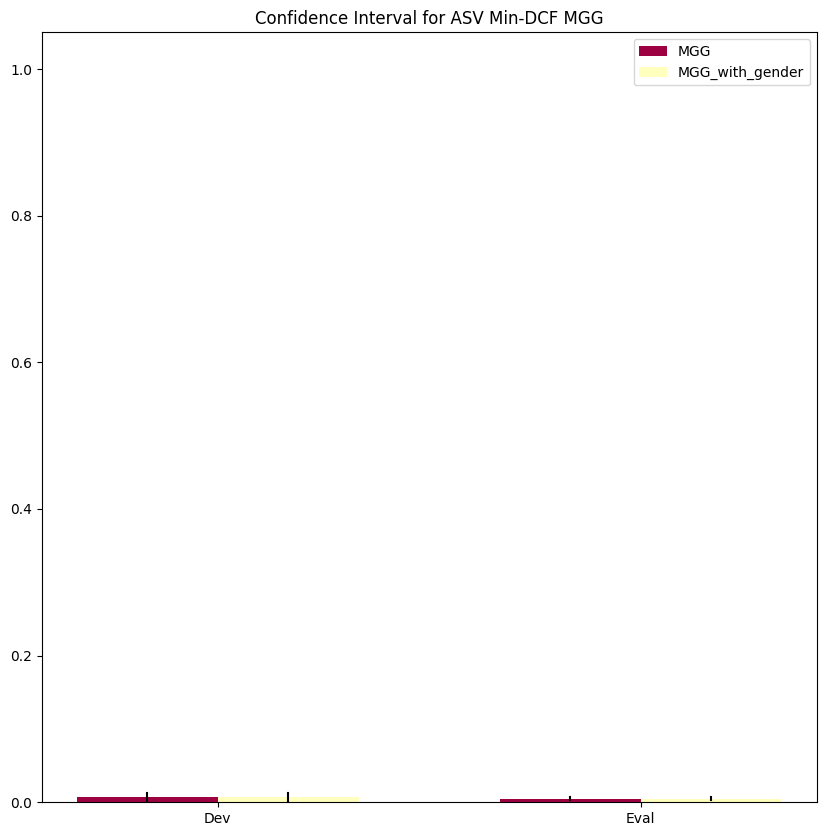

In [34]:
barplot_with_ci(data, figsize=(10,10),y_limit = [1,1],eer = False,title = 'Confidence Interval for ASV Min-DCF MGG')

# MGG Independent:

# Dev: 

In [35]:
def metric(labels, scores):
    Prior_target =  0.99

    Prior_non_target = 1-Prior_target

    cost_model_dcf = {
        'Cmiss_asv': 1,      # Cost of ASV falsely rejecting target
        'Cfa_asv': 10,       # Cost of ASV falsely accepting nontarget
    }
    dcf_list = []
    tar_female_idx = np.where(labels == 3)[0]
    non_female_idx = np.where(labels == 2)[0]
    tar_male_idx = np.where(labels == 1)[0]
    non_male_idx = np.where(labels == 0)[0]
    
    nontarget_scores_female = scores[non_female_idx]
    target_scores_female = scores[tar_female_idx]
    nontarget_scores_male = scores[non_male_idx]
    target_scores_male = scores[tar_male_idx]
    
    #asv_score_all_wizard_eval = 0.333
    asv_score_all_wizard_dev = 0.314
    
    summing_female_nontar = np.sum(nontarget_scores_female >= asv_score_all_wizard_dev)
    summing_female_tar =  np.sum(target_scores_female < asv_score_all_wizard_dev)
    summing_male_nontar = np.sum(nontarget_scores_male >= asv_score_all_wizard_dev)
    summing_male_tar =  np.sum(target_scores_male < asv_score_all_wizard_dev)
    
    Pmiss_asv = (summing_female_tar + summing_male_tar) / (target_scores_male.size+target_scores_female.size)
    Pfa_asv = (summing_female_nontar +  summing_male_nontar )/ (nontarget_scores_male.size+nontarget_scores_female.size)
        
    dcf = dcf_formula(Pfa_asv,Pmiss_asv,Prior_target = Prior_target,Prior_non_target= Prior_non_target,cost_model_dcf=cost_model_dcf,is_print=False)
   
    
    dcf_list.append(dcf)

    return np.min(dcf_list)


#All MGG:
#DEV
gender_type = "male"
target_scores_male = results_list_dev_all.loc[(results_list_dev_all['gender'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_male =results_list_dev_all.loc[(results_list_dev_all['gender'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "nontarget")]["pred_scores"]

gender_type = "female"
target_scores_female = results_list_dev_all.loc[(results_list_dev_all['gender'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_female =results_list_dev_all.loc[(results_list_dev_all['gender'] == gender_type) & (results_list_dev_all['label_ground_truth'] == "nontarget")]["pred_scores"]

scores_male = np.concatenate((target_scores_male,nontarget_scores_male))

labels_male = np.concatenate((np.ones(len(target_scores_male)),np.zeros(len(nontarget_scores_male))))

scores_female = np.concatenate((target_scores_female,nontarget_scores_female))

labels_female = np.concatenate((np.ones(len(target_scores_female)),np.zeros(len(nontarget_scores_female))))

cond = (results_list_dev_all['label_ground_truth'] == "target") | (results_list_dev_all['label_ground_truth'] == "nontarget")
labels_female[labels_female == 1] = 3
labels_female[labels_female == 0] = 2

labels = np.concatenate((labels_male,labels_female))
scores = np.concatenate((scores_male,scores_female))
speakers = results_list_dev_all.loc[cond]["speaker_id"].values

labels = labels.astype(int)
res_dev_all = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha,samples2 = None)
res_dev_all

(0.009307827179232203, (0.003560343369295749, 0.016577502466389366))

# Eval:

In [36]:
def metric(labels, scores):
    Prior_target =  0.99

    Prior_non_target = 1-Prior_target

    cost_model_dcf = {
        'Cmiss_asv': 1,      # Cost of ASV falsely rejecting target
        'Cfa_asv': 10,       # Cost of ASV falsely accepting nontarget
    }
    dcf_list = []
    tar_female_idx = np.where(labels == 3)[0]
    non_female_idx = np.where(labels == 2)[0]
    tar_male_idx = np.where(labels == 1)[0]
    non_male_idx = np.where(labels == 0)[0]
    
    nontarget_scores_female = scores[non_female_idx]
    target_scores_female = scores[tar_female_idx]
    nontarget_scores_male = scores[non_male_idx]
    target_scores_male = scores[tar_male_idx]
    
    asv_score_all_wizard_eval = 0.333
    #asv_score_all_wizard_dev = 0.314
    
    summing_female_nontar = np.sum(nontarget_scores_female >= asv_score_all_wizard_eval)
    summing_female_tar =  np.sum(target_scores_female < asv_score_all_wizard_eval)
    summing_male_nontar = np.sum(nontarget_scores_male >= asv_score_all_wizard_eval)
    summing_male_tar =  np.sum(target_scores_male < asv_score_all_wizard_eval)
    
    Pmiss_asv = (summing_female_tar + summing_male_tar) / (target_scores_male.size+target_scores_female.size)
    Pfa_asv = (summing_female_nontar +  summing_male_nontar )/ (nontarget_scores_male.size+nontarget_scores_female.size)
        
    dcf = dcf_formula(Pfa_asv,Pmiss_asv,Prior_target = Prior_target,Prior_non_target= Prior_non_target,cost_model_dcf=cost_model_dcf,is_print=False)
   
    
    dcf_list.append(dcf)

    return np.min(dcf_list)

#EVAL
#All MGG:
#EVAL
gender_type = "male"
target_scores_male = results_list_eval_all.loc[(results_list_eval_all['gender'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_male =results_list_eval_all.loc[(results_list_eval_all['gender'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "nontarget")]["pred_scores"]

gender_type = "female"
target_scores_female = results_list_eval_all.loc[(results_list_eval_all['gender'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "target")]["pred_scores"]
nontarget_scores_female = results_list_eval_all.loc[(results_list_eval_all['gender'] == gender_type) & (results_list_eval_all['label_ground_truth'] == "nontarget")]["pred_scores"]

scores_male = np.concatenate((target_scores_male,nontarget_scores_male))

labels_male = np.concatenate((np.ones(len(target_scores_male)),np.zeros(len(nontarget_scores_male))))

scores_female = np.concatenate((target_scores_female,nontarget_scores_female))

labels_female = np.concatenate((np.ones(len(target_scores_female)),np.zeros(len(nontarget_scores_female))))

cond = (results_list_eval_all['label_ground_truth'] == "target") | (results_list_eval_all['label_ground_truth'] == "nontarget")
labels_female[labels_female == 1] = 3
labels_female[labels_female == 0] = 2

labels = np.concatenate((labels_male,labels_female))
scores = np.concatenate((scores_male,scores_female))
speakers = results_list_eval_all.loc[cond]["speaker_id"].values

labels = labels.astype(int)
res_eval_all = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha,samples2 = None)

data = {}
data['MGG'] = {'Dev': res_dev_all, 'Eval': res_eval_all}
res_eval_all

(0.004608423254049556, (0.0025583249068712568, 0.007657812490382335))

{'Dev': (0.009307827179232203, (0.003560343369295749, 0.016577502466389366)), 'Eval': (0.004608423254049556, (0.0025583249068712568, 0.007657812490382335))}


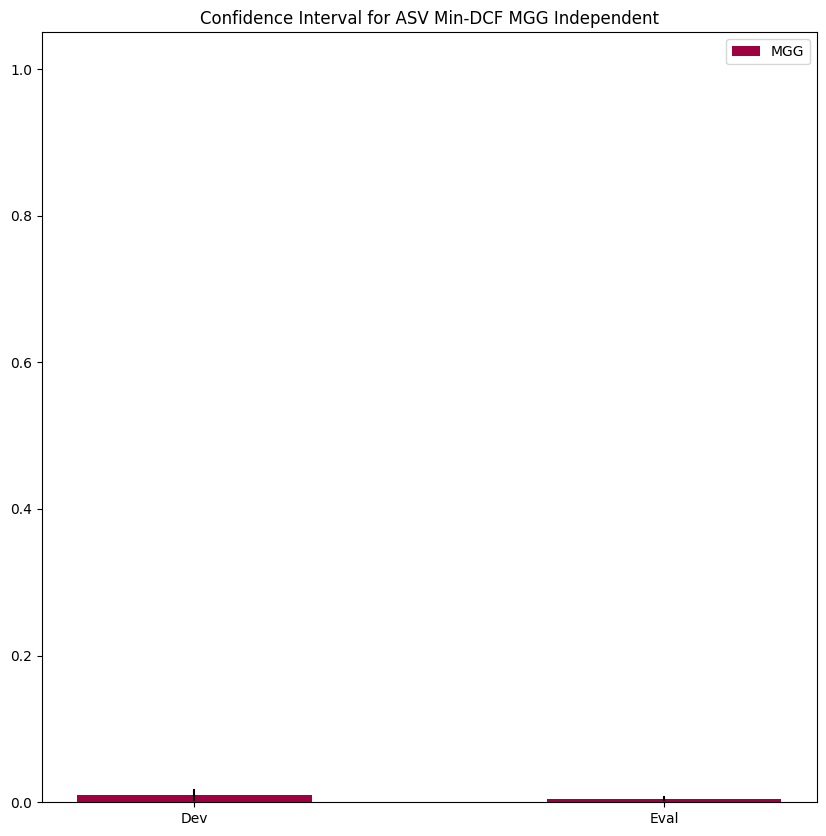

In [37]:
barplot_with_ci(data, figsize=(10,10),y_limit = [1,1],eer = False,title = 'Confidence Interval for ASV Min-DCF MGG Independent')